# Sparse sensors, smooth maps and uncertainty

An original geospatial learning extension, connected to the map-based visual reasoning in
[Awesome Astra's Seoul 3D Atlas](https://github.com/magiccreator-ai/awesome-gpt-6-astra#seoul-3d-atlas).
[Creator demo](https://seoul-3d-atlas.synabreu.chatgpt.site/) credits synabreu.
This interpolation exercise is new to this repo; it is not a reconstruction of that demo.

**Learn:** distinguish observed samples, estimated values and support from nearby data.
**Predict:** does a smooth temperature map mean the temperature is known everywhere?
All sensor locations and temperatures are invented, on a local kilometer grid.


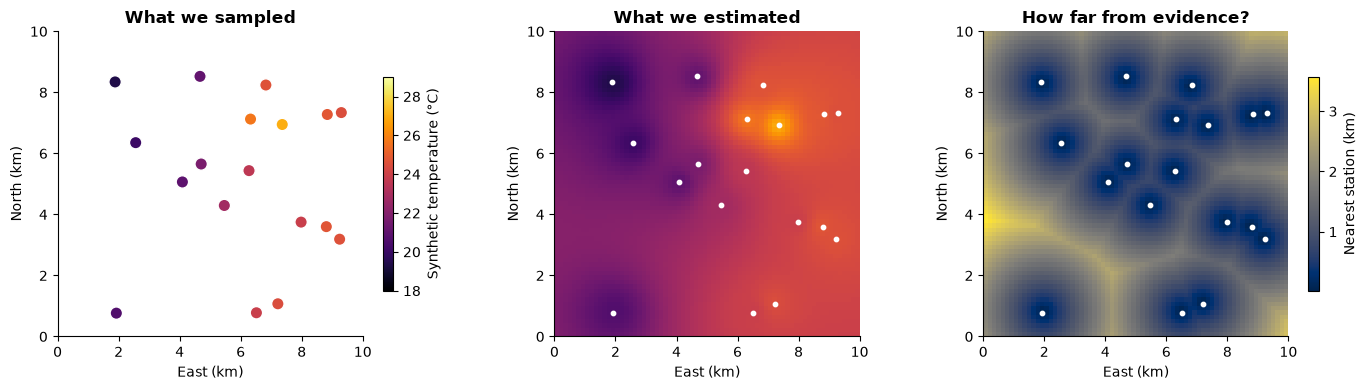

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style
style()
rng = np.random.default_rng(14)
def field(x,y):
    return 20+.6*x-.25*y+4*np.exp(-((x-7)**2+(y-7)**2)/3)
stations = rng.uniform(.5,9.5,(18,2))
observations = field(*stations.T)+rng.normal(0,.3,len(stations))
axis = np.linspace(0,10,70)
X,Y = np.meshgrid(axis,axis)
query = np.column_stack((X.ravel(),Y.ravel()))
def idw(query,points,values,power=2):
    distance = np.linalg.norm(query[:,None,:]-points[None,:,:],axis=2)
    weights = 1/np.maximum(distance,1e-12)**power
    estimate = (weights @ values)/weights.sum(axis=1)
    exact = distance.min(axis=1) < 1e-12
    estimate[exact] = values[distance[exact].argmin(axis=1)]
    return estimate,distance.min(axis=1)
estimate,support = idw(query,stations,observations)
Z = estimate.reshape(X.shape)
fig,axes = plt.subplots(1,3,figsize=(14,4))
im = axes[0].scatter(*stations.T,c=observations,s=80,cmap='inferno',vmin=18,vmax=29,edgecolor='white')
fig.colorbar(im,ax=axes[0],label='Synthetic temperature (°C)',shrink=.7)
im = axes[1].imshow(Z,origin='lower',extent=(0,10,0,10),cmap='inferno',vmin=18,vmax=29)
axes[1].scatter(*stations.T,c='white',s=10)
im = axes[2].imshow(support.reshape(X.shape),origin='lower',extent=(0,10,0,10),cmap='cividis')
axes[2].scatter(*stations.T,c='white',s=10)
fig.colorbar(im,ax=axes[2],label='Nearest station (km)',shrink=.7)
for ax,title in zip(axes,['What we sampled','What we estimated','How far from evidence?']):
    ax.set(title=title,xlabel='East (km)',ylabel='North (km)',xlim=(0,10),ylim=(0,10),aspect='equal')
fig.tight_layout()
plt.show()


Inverse-distance weighting gives nearby measurements more influence. It assumes spatial similarity
without learning a physical process. The right panel measures **data proximity**, not calibrated
statistical uncertainty. A nearby sensor can still be noisy or separated by a physical boundary.


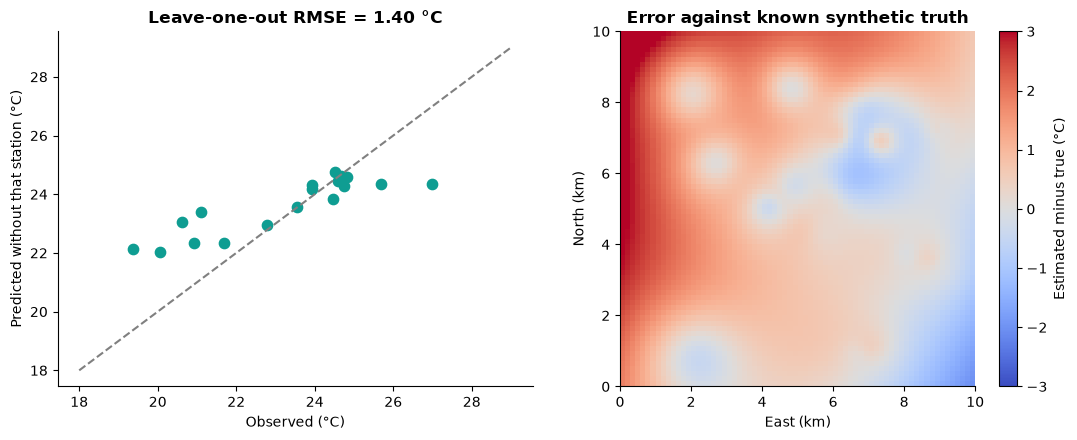

In [2]:
predicted = []
for i in range(len(stations)):
    keep = np.arange(len(stations)) != i
    value,_ = idw(stations[i:i+1],stations[keep],observations[keep])
    predicted.append(value[0])
predicted = np.array(predicted)
loo_rmse = np.sqrt(np.mean((predicted-observations)**2))
truth_error = Z-field(X,Y)
fig,axes = plt.subplots(1,2,figsize=(11,4.5))
axes[0].scatter(observations,predicted,s=55)
axes[0].plot([18,29],[18,29],'--',color='gray')
axes[0].set(title=f'Leave-one-out RMSE = {loo_rmse:.2f} °C',xlabel='Observed (°C)',ylabel='Predicted without that station (°C)')
im = axes[1].imshow(truth_error,origin='lower',extent=(0,10,0,10),cmap='coolwarm',vmin=-3,vmax=3)
axes[1].set(title='Error against known synthetic truth',xlabel='East (km)',ylabel='North (km)')
fig.colorbar(im,ax=axes[1],label='Estimated minus true (°C)')
fig.tight_layout()
plt.show()
assert np.allclose(idw(stations,stations,observations)[0],observations)
assert observations.min() <= estimate.min() <= estimate.max() <= observations.max()


**Experiment:** cluster every station in the west. Predict where error will grow. Increase the
weighting power to four and compare local detail with held-out error. More texture is not always
more accuracy. Leave-one-out validation can itself look optimistic when samples are clustered;
withholding entire spatial blocks is a stronger test of transfer to distant locations.
